# 📈 Resumos e um Pouco de Visualização no Pandas

![Jupyter](https://img.shields.io/badge/Jupyter-111827?style=flat-square&logo=jupyter&logoColor=F37626)
![Python](https://img.shields.io/badge/Python-111827?style=flat-square&logo=python&logoColor=3776AB)
![Pandas](https://img.shields.io/badge/Pandas-150458?style=flat-square&logo=pandas&logoColor=white)
![Python Version](https://img.shields.io/badge/python-3.14+-blue)
![Tópico](https://img.shields.io/badge/tópico-agregação%20%7C%20gráficos-teal)
![Dificuldade](https://img.shields.io/badge/dificuldade-Avançado-red)
![Pré-req](https://img.shields.io/badge/pré--req-dataframe%20%7C%20merge-purple)
![Biblioteca](https://img.shields.io/badge/requer-pip%20install%20pandas%20matplotlib-orange)

> Vamos ver alguns métodos para analisar nossas tabelas (DataFrames) e usar os gráficos padrão do pandas — no projeto de DataScience veremos opções mais bonitas, mas essas já resolvem muito bem o dia a dia.


## 📋 Conteúdo

1. [Preparando as bases de dados](#️-1-preparando-as-bases-de-dados)
2. [Qual cliente comprou mais vezes?](#-2-qual-cliente-comprou-mais-vezes)
3. [Qual o produto que mais vendeu?](#-3-qual-o-produto-que-mais-vendeu)
4. [Pegando o maior valor](#-4-pegando-o-maior-valor)
5. [Qual produto que menos vendeu?](#-5-qual-produto-que-menos-vendeu)

---

> 💡 **Dica:** o pandas usa o `matplotlib` (que vimos na seção de "módulos e bibliotecas") para plotar gráficos. Se quiser personalizar mais do que o padrão do pandas, importe o `matplotlib` e use os métodos dele diretamente.

---

## ⚙️ 1. Preparando as bases de dados

- Preparando as bases de dados (o que fizemos na última aula)

In [ ]:
import pandas as pd

# importando os arquivos
vendas_df = pd.read_csv(r'../spec/Contoso - Vendas - 2017.csv', sep=';', encoding='latin1')
produtos_df = pd.read_csv(r'../spec/Contoso - Produtos Cadastro Completo.csv', sep=';', encoding='latin1')
lojas_df = pd.read_csv(r'../spec/Contoso - Lojas.csv', sep=';', encoding='latin1')
clientes_df = pd.read_csv(r'../spec/Contoso - Clientes.csv', sep=';', encoding='latin1')


# Ajustar nome das colunas
produtos_df.rename(columns={'ÿNome do Produto': 'Nome do Produto'}, inplace=True)
clientes_df.rename(columns={'ÿID Cliente': 'ID Cliente'}, inplace=True)
lojas_df.rename(columns={'ÿID Loja': 'ID Loja'}, inplace=True)


# limpando apenas as colunas que queremos
clientes_df = clientes_df[['ID Cliente', 'E-mail']]
produtos_df = produtos_df[['ID Produto', 'Nome do Produto']]
lojas_df = lojas_df[['ID Loja', 'Nome da Loja']]


# mesclando e renomeando os dataframes
vendas_df = vendas_df.merge(produtos_df, on='ID Produto')
vendas_df = vendas_df.merge(lojas_df, on='ID Loja')
vendas_df = vendas_df.merge(clientes_df, on='ID Cliente').rename(columns={'E-mail': 'E-mail do Cliente'})

#print na tela
display(vendas_df[0:21:2])

,Numero da Venda,Data da Venda,Data do Envio,ID Canal,ID Loja,ID Produto,ID Promocao,ID Cliente,Quantidade Vendida,Quantidade Devolvida,Nome do Produto,Nome da Loja,E-mail do Cliente
0,1,01/01/2017,02/01/2017,1,86,981,2,6825,9,1,A. Datum Advanced Digital Camera M300 Pink,Loja Contoso Austin,rbrumfieldmy@ameblo.jp
2,3,01/01/2017,01/01/2017,0,294,1444,5,19730,13,1,"The Phone Company Touch Screen Phones 26-2.2"" ...",Loja Contoso Tehran No.2,kgorriekd@bandcamp.com
4,5,01/01/2017,07/01/2017,6,94,1106,2,22617,4,1,Contoso SLR Camera M146 Orange,Loja Contoso Grand Prairie,jacob4@adventure-works.com
6,7,01/01/2017,09/01/2017,8,10,1261,2,11720,4,1,Contoso Multi-Use Terminal Cable E308 White,Loja Contoso Wapato,tlefeuvrek1@si.edu
8,9,01/01/2017,05/01/2017,4,213,1509,10,32396,8,1,The Phone Company Smart phones Unlocked Intern...,Loja Contoso Knotty Ash,shannon30@adventure-works.com
10,11,01/01/2017,08/01/2017,7,257,900,5,30488,6,1,SV Keyboard E10 White,Loja Contoso Kolkata,arturo25@adventure-works.com
12,13,01/01/2017,01/01/2017,0,13,167,2,25632,4,1,SV 8xDVD E100 Black,Loja Contoso Snoqualmie,kaitlyn22@adventure-works.com
14,15,01/01/2017,01/01/2017,0,207,1602,10,36839,8,1,SV DVD 12-Inch Player Portable M400 Black,Loja Contoso Lancashire,raymond2@adventure-works.com
16,17,01/01/2017,01/01/2017,0,225,1383,10,7991,4,1,Contoso Dual Handset Cordless Phone System E20...,Loja Contoso Torino,tstapforthrk@yale.edu
18,19,01/01/2017,02/01/2017,1,211,1402,10,24240,8,1,Contoso Expandable 4-Handset Cordless Phone Sy...,Loja Contoso Stockport,diana21@adventure-works.com


## 🙋 2. Qual cliente comprou mais vezes?

| Método | O que faz |
|--------|-----------|
| `.value_counts()` | Conta quantas vezes cada valor aparece na coluna/Series |
| `.plot()` | Exibe um gráfico a partir dos dados (usa o `matplotlib` por trás) |

> 💡 **Dica:** `.value_counts()` já retorna o resultado ordenado do maior para o menor — ótimo para rankings.

E-mail do Cliente
karen33@adventure-works.com      77
chloe77@adventure-works.com      74
julia43@adventure-works.com      69
gilbert9@adventure-works.com     68
destiny66@adventure-works.com    68
                                 ..
mblemen9o@ebay.com                1
rebecca15@adventure-works.com     1
kevin10@adventure-works.com       1
siliffe8l@spotify.com             1
clifford8@adventure-works.com     1
Name: count, Length: 38907, dtype: int64

<Axes: xlabel='E-mail do Cliente'>

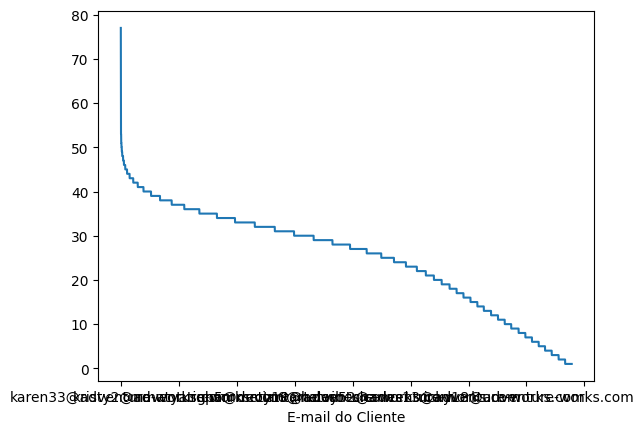

In [15]:
contagem_clientes = vendas_df['E-mail do Cliente'].value_counts()
display(contagem_clientes)

contagem_clientes.plot()

## 📦 3. Qual o produto que mais vendeu?

- Usaremos o `.groupby` para agrupar o nosso DataFrame de acordo com o que queremos (somando as quantidades de vendas, por exemplo)

```python
dataframe.groupby('coluna_para_agrupar')['coluna_para_somar'].sum()
```

| Parte | Significado |
|-------|-------------|
| `groupby('coluna_para_agrupar')` | Agrupa as linhas que têm o mesmo valor nessa coluna |
| `['coluna_para_somar'].sum()` | Soma os valores dessa coluna dentro de cada grupo |

In [13]:
vendas_por_produto = vendas_df.groupby('Nome do Produto')['Quantidade Vendida'].sum()
display(vendas_por_produto[0:21:1])

Nome do Produto
A. Datum Advanced Digital Camera M300 Azure        8999
A. Datum Advanced Digital Camera M300 Black       12087
A. Datum Advanced Digital Camera M300 Green       11400
A. Datum Advanced Digital Camera M300 Grey        10713
A. Datum Advanced Digital Camera M300 Orange      12181
A. Datum Advanced Digital Camera M300 Pink        11121
A. Datum Advanced Digital Camera M300 Silver      10776
A. Datum All in One Digital Camera M200 Black     11411
A. Datum All in One Digital Camera M200 Green     11280
A. Datum All in One Digital Camera M200 Grey      11638
A. Datum All in One Digital Camera M200 Orange     8797
A. Datum All in One Digital Camera M200 Pink      11571
A. Datum All in One Digital Camera M200 Silver    11820
A. Datum Bridge Digital Camera M300 Azure         10869
A. Datum Bridge Digital Camera M300 Black          9954
A. Datum Bridge Digital Camera M300 Green         10948
A. Datum Bridge Digital Camera M300 Grey          11425
A. Datum Bridge Digital Camera M

## 🏆 4. Pegando o maior valor

Agora precisamos pegar o maior valor. Temos 2 formas:

1. **Ordenar** o DataFrame em ordem decrescente de `Quantidade Vendida` — método `.sort_values`
2. **Pegar o maior valor diretamente** — métodos `.max()` e `.idxmax()`

| Método | O que faz |
|--------|-----------|
| `.sort_values(ascending=False)` | Ordena do maior para o menor valor |
| `.max()` | Retorna o maior valor |
| `.idxmax()` | Retorna o índice (nome/label) onde está o maior valor |

Nome do Produto
Cigarette Lighter Adapter for Contoso Phones E110 White                        114300
Contoso Rubberized Skin BlackBerry E100 Black                                  113880
Contoso Rubberized Skin BlackBerry E100 White                                  113440
Contoso In-Line Coupler E180 Silver                                            113400
Contoso Rubberized Skin BlackBerry E100 Silver                                 113060
Contoso In-Line Coupler E180 Black                                             109100
Cigarette Lighter Adapter for Contoso Phones E110 Red                          107020
Contoso Rubberized Snap-On Cover Hard Case Cell Phone Protector E160 Silver    106460
Contoso In-Line Coupler E180 White                                             105880
Contoso Rubberized Snap-On Cover Hard Case Cell Phone Protector E160 White     105520
Contoso Rubberized Snap-On Cover Hard Case Cell Phone Protector E160 Pink      105060
Cigarette Lighter Adapter for Contoso 

<Axes: xlabel='Nome do Produto'>

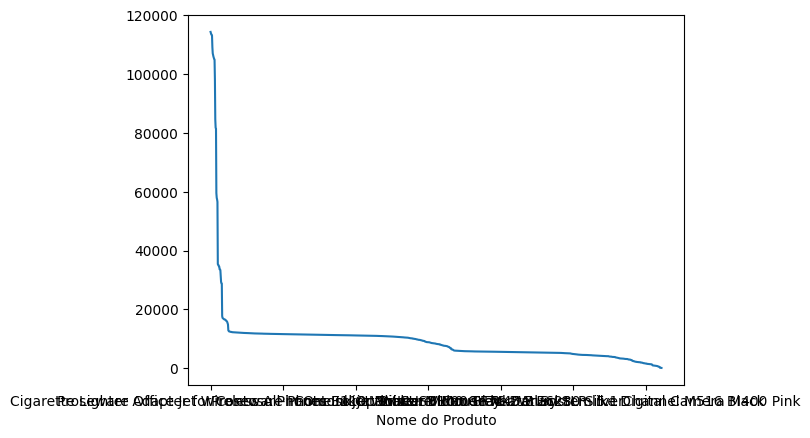

In [14]:
# ordenando o dataframe
vendas_por_produto = vendas_por_produto.sort_values(ascending=False)
display(vendas_por_produto[0:21:1])

# podemos plotar em um gráfico
vendas_por_produto.plot()

In [11]:
# pegando o maior valor e seu índice
print(vendas_por_produto.max())
print(vendas_por_produto.idxmax())

114300
Cigarette Lighter Adapter for Contoso Phones E110 White


## 📉 5. Qual produto que menos vendeu?

- Já temos uma lista criada para isso (`vendas_por_produto`), basta verificarmos o final da lista (já que ela está ordenada) ou então usarmos os métodos:
    1. `.min()`
    2. `.idxmin()`

In [12]:
# verificando o final da lista já ordenada
display(vendas_por_produto.tail())

# ou pegando o menor valor e seu índice diretamente
print(vendas_por_produto.min())
print(vendas_por_produto.idxmin())

Nome do Produto
Contoso 4GB Portable MP3 Player M450 Black     136
SV 16xDVD E340 Black                           124
Contoso 4GB Portable MP3 Player M450 Yellow    110
Contoso 4GB Portable MP3 Player M450 White      94
SV 16xDVD E340 Silver                           86
Name: Quantidade Vendida, dtype: int64

86
SV 16xDVD E340 Silver
